# Photoinduced iron-catalyzed cycloisomerization

Alkynols to cyclic enol ethers under photochemical iron catalysis (Lehnherr *et al.*, *J. Am. Chem. Soc.* **2018**, 140, 13843–13853). See `README.md` in this folder.

`kinetics.txt` has four traces as `(Time, A, catT)` groups of 3 columns. `t = 0` is used only to read `S0` / `cat0`.

Two settings are run:

- **Skip curve 4.** Curves 1–3 start at raw `[S]_0 = 0.6`; curve 4 starts at `0.3`. Dropping it keeps a matched initial-composition set (only `cat0` varies).
- **Keep curve 4.** Use every published trace, including the lower-`[S]_0` experiment.

Each seed samples 12 points (`t > 0`); five default ensemble members are averaged over 20 seeds.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "src").is_dir() and (p / "checkpoints").is_dir():
        ROOT = p
        break

CASE_DIR = ROOT / "experiments" / "photoinduced_iron_cycloisomerization"
DATA_PATH = CASE_DIR / "kinetics.txt"
CKPT_PATHS = [ROOT / "checkpoints" / f"default_member_{i}.pth" for i in range(5)]

N_SEEDS = 20
N_TOTAL_SAMPLES = 12
PRINT_SEED = 0
GPU = None


In [2]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.patches import Patch

if GPU is not None:
    os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
    os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU)

sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

from eval import load_model
from utils.scattered_dataset import ScatteredKineticDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
for p in CKPT_PATHS:
    print(" ", Path(p).name)

models = []
for p in CKPT_PATHS:
    model, params, _ckpt = load_model(str(p), device)
    models.append(model)
    print(Path(p).name, params)


device: cuda
  default_member_0.pth
  default_member_1.pth
  default_member_2.pth
  default_member_3.pth
  default_member_4.pth
default_member_0.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
default_member_1.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
default_member_2.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
default_member_3.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
default_member_4.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}


In [3]:
def load_curves(path, skip_curve4):
    raw_df = pd.read_csv(path, sep=r"\s+", engine="python")
    curves = []
    for i in range(0, 12, 3):
        temp_df = raw_df.iloc[:, i : i + 3].copy()
        temp_df.columns = ["t", "S_raw", "cat_raw"]
        temp_df = temp_df.dropna(subset=["t"])
        s0_val_raw = temp_df["S_raw"].iloc[0]
        cat_raw_val = temp_df["cat_raw"].dropna().iloc[0]
        curr_idx = i // 3
        if skip_curve4 and curr_idx == 3:
            continue
        temp_df["curve_idx"] = curr_idx
        temp_df["cat0"] = cat_raw_val / (s0_val_raw + 1e-12)
        temp_df["S0"] = 1.0
        temp_df["P0"] = 0.0
        temp_df["Pt"] = (s0_val_raw - temp_df["S_raw"]) / (s0_val_raw + 1e-12)
        temp_df["St"] = 1.0 - temp_df["Pt"]
        temp_df["RP"] = temp_df["Pt"]
        temp_df = temp_df[temp_df["t"] > 0].reset_index(drop=True)
        curves.append(temp_df)
    return curves


def run_seeds(curves, models, n_seeds, n_total, print_seed=None):
    all_probs = []
    for s in range(n_seeds):
        n_curves = len(curves)
        per = n_total // n_curves
        extra = n_total % n_curves
        parts = []
        for i, c_df in enumerate(curves):
            n_to_sample = min(per + (1 if i < extra else 0), len(c_df))
            parts.append(c_df.sample(n=n_to_sample, random_state=s))
        sampled_df = pd.concat(parts, ignore_index=True).sort_values("t").reset_index(drop=True)
        if print_seed is not None and s == print_seed:
            show = sampled_df.copy()
            show.insert(0, "Point", np.arange(1, len(show) + 1))
            cols = ["Point", "curve_idx", "t", "cat0", "S0", "P0", "St", "Pt"]
            print(f"\n===== seed={print_seed}, N={len(show)}, curves={sorted(show['curve_idx'].unique().tolist())} =====")
            print(show[cols].to_string(index=False, float_format=lambda x: f"{x:.6g}"))
        ds = ScatteredKineticDataset(sampled_df, use_tau=False, noise_std=0.0)
        feat, _ = ds[0]
        x = feat.unsqueeze(0).to(device)
        member = []
        with torch.no_grad():
            for model in models:
                member.append(torch.softmax(model(x), dim=1).cpu().numpy()[0])
        all_probs.append(np.mean(member, axis=0))
    all_probs = np.array(all_probs)
    avg = all_probs.mean(axis=0)
    pred = int(np.argmax(avg))
    return all_probs, avg, pred


In [4]:
SETTINGS = [
    {
        "key": "skip_curve4",
        "title": "Skip curve 4",
        "skip_curve4": True,
        "reason": "Curves 1-3 share raw [S]0=0.6; curve 4 has [S]0=0.3. Skipping keeps matched initial composition.",
    },
    {
        "key": "keep_curve4",
        "title": "Keep curve 4",
        "skip_curve4": False,
        "reason": "Use all four published traces, including the lower-[S]0 experiment.",
    },
]

results = {}
for cfg in SETTINGS:
    curves = load_curves(DATA_PATH, skip_curve4=cfg["skip_curve4"])
    print(f"\n=== {cfg['title']} ===")
    print(cfg["reason"])
    print("curves:", len(curves), "ids:", [int(c['curve_idx'].iloc[0]) + 1 for c in curves],
          "points/curve (t>0):", [len(c) for c in curves])
    all_probs, avg, pred = run_seeds(curves, models, N_SEEDS, N_TOTAL_SAMPLES, PRINT_SEED)
    results[cfg["key"]] = {**cfg, "curves": curves, "all_probs": all_probs, "avg": avg, "pred": pred}
    print(f"prediction: M{pred + 1}  avg={avg[pred]:.2%}  std={np.std(all_probs[:, pred]):.4f}")
    top = np.argsort(avg)[::-1]
    for rank in range(3):
        i = top[rank]
        print(f"  top {rank + 1}: M{i + 1}  {avg[i]:.2%}  (std {np.std(all_probs[:, i]):.4f})")



=== Skip curve 4 ===
Curves 1-3 share raw [S]0=0.6; curve 4 has [S]0=0.3. Skipping keeps matched initial composition.
curves: 3 ids: [1, 2, 3] points/curve (t>0): [25, 25, 25]

===== seed=0, N=12, curves=[0, 1, 2] =====
 Point  curve_idx        t    cat0  S0  P0        St       Pt
     1          1 0.351821   0.015   1   0  0.901296 0.098704
     2          2 0.411949    0.03   1   0  0.776783 0.223217
     3          0 0.412063 0.00375   1   0  0.897908 0.102092
     4          1    0.593   0.015   1   0  0.766435 0.233565
     5          2 0.653334    0.03   1   0   0.56576  0.43424
     6          0 0.733672 0.00375   1   0  0.780263 0.219737
     7          1  1.49775   0.015   1   0  0.330276 0.669724
     8          2  1.57782    0.03   1   0  0.102084 0.897916
     9          1  1.74021   0.015   1   0   0.25426  0.74574
    10          2  1.81908    0.03   1   0 0.0605436 0.939456
    11          0  2.24121 0.00375   1   0  0.347744 0.652256
    12          0  3.06532 0.00375 

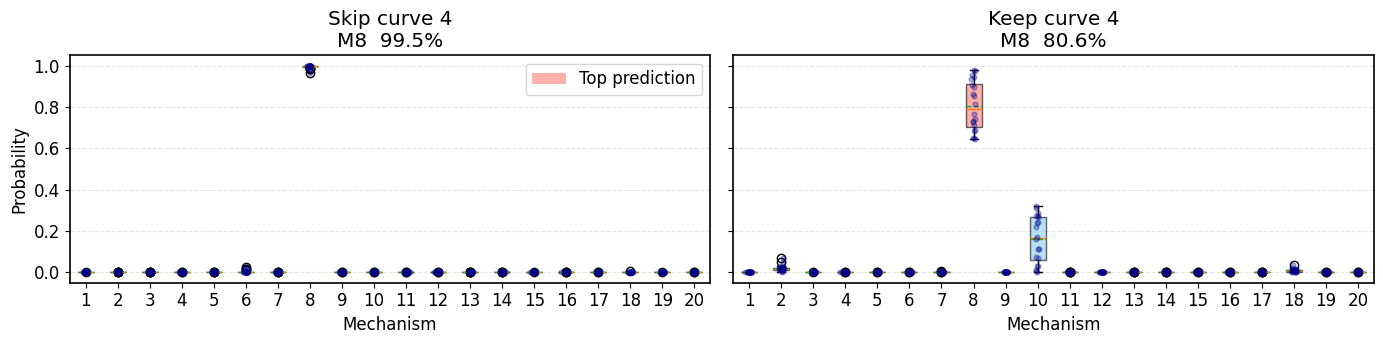

In [5]:
plt.rcParams.update({"font.size": 12, "axes.linewidth": 1.2})
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6), sharey=True)
rng = np.random.default_rng(0)

for ax, cfg in zip(axes, SETTINGS):
    r = results[cfg["key"]]
    all_probs, avg, pred = r["all_probs"], r["avg"], r["pred"]
    box = ax.boxplot(
        all_probs, positions=range(1, 21), patch_artist=True,
        showmeans=True, meanline=True, zorder=2,
    )
    for patch in box["boxes"]:
        patch.set_facecolor("skyblue")
        patch.set_alpha(0.6)
    box["boxes"][pred].set_facecolor("salmon")
    for i in range(20):
        y = all_probs[:, i]
        xj = rng.normal(i + 1, 0.04, size=len(y))
        ax.scatter(xj, y, alpha=0.3, s=12, color="darkblue", zorder=3)
    ax.set_title(f"{cfg['title']}\nM{pred + 1}  {avg[pred]:.1%}")
    ax.set_xlabel("Mechanism")
    ax.set_xticks(range(1, 21))
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", ls="--", alpha=0.3)

axes[0].set_ylabel("Probability")
axes[0].legend(
    handles=[Patch(facecolor="salmon", alpha=0.6, label="Top prediction")],
    loc="upper right",
)
fig.tight_layout()
plt.show()
